<a href="https://colab.research.google.com/github/natenorris10/MAT-422/blob/main/HW_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Algebra Homework 1.2

In [60]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.linalg import null_space

###1.2.1 - Linear Spaces

A vector space is a set of vectors where addition and scalar multiplication is defined, and the vectors contained in the set satisfy a set of axioms.  A linear subspace $U$ is a subset of a vector space $V$ if the vectors contained in $U$ follow the same operations of addition and scalar multiplication.

In [ ]:
# Creating vectors and scalar
u = np.array([1, 2, 3])
v = np.array([2, -3, 5])
alpha = 1.2

print(f"u = {u}")
print(f"v = {v}")
print(f"alpha = {alpha}\n")

# closed under addition and multiplication
print(f"Addition: u + v = {u + v}")
print(f"Multiplication: alpha * u = {alpha * u}\n")

# Satisfies inverse
print(f"u + (-u) = {u + (-u)}")

u = [1 2 3]
v = [ 2 -3  5]
alpha = 1.2

Addition: u + v = [ 3 -1  8]
Multiplication: alpha * u = [1.2 2.4 3.6]

u + (-u) = [0 0 0]


We see that given two vectors $\textbf{u},\textbf{v}$ in some subspace $U$, we can see that their addition is still contained in $\mathbb{R}^3$.  Also, given a scalar $\alpha$, the resulting vector from multiplying by the scalar is also still contained in the vector space, $\alpha\mathbf{u} \in \mathbb{R}^3$.  Thus, $U \in \mathbb{R}^3$.

A linear combination is the sum of vectors $\mathbf{v}_1, \mathbf{v}_2, ..., \mathbf{v}_n$, in a vector space $V$, and their scalars, $\alpha_1, \alpha_2, ..., \alpha_n$, in the form $\alpha_1\mathbf{v}_1 + \alpha_2\mathbf{v}_2 + \cdots + \alpha_n\mathbf{v}_n$. A span is then the set of all linear combinations of $\mathbf{v}_1, \mathbf{v}_2, ..., \mathbf{v}_n$.

In [ ]:
# Scalars for a linear combination
alpha_1 = 4
alpha_2 = -2

print(f"(alpha_1*u) + (alpha_2*v) = {alpha_1*u + alpha_2*v}")

(alpha_1*u) + (alpha_2*v) = [ 0 14  2]


It would be impossible to write out the entire list of linear combinations in this case.  But, we can see at least given the above example that $\alpha_1\mathbf{u} + \alpha_2\mathbf{v} \in \mathbf{span}(\mathbf{u}, \mathbf{v})$.

The column space of a $m \times n$ matrix $A$, where $A \in \mathbb{R}^{m \times n}$, is the span of all the columns in the matrix, denoted as col($A$).  Basically, this is the set of all linear combinations of all column vectors in matrix $A$.

In [ ]:
# Generate random matrix
seed = np.random.default_rng(seed=10)

def matrix_generator(row, col):
  return seed.integers(0, 51, (row, col))

matrix_A = matrix_generator(3,3)
print(matrix_A)

[[39 48 13]
 [10 40 42]
 [26  7 42]]


Given the matrix generated, the column space would follow this form: col($A$) = $\alpha\begin{bmatrix} 39 \\ 10 \\ 26 \end{bmatrix} + \beta\begin{bmatrix} 48 \\ 40 \\ 7 \end{bmatrix} + \gamma\begin{bmatrix} 13 \\ 42 \\ 42 \end{bmatrix}$, where $\alpha, \beta$, and $\gamma$ are scalars.

Vectors are considered linearly independent if none of them can be written as a linear combination of each other.  In mathematical terms, it must be the case that $c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_n\mathbf{v}_n = \mathbf{0}$, where the scalars $c_1, c_2, ..., c_n$ must be equal to $0$.  If the equation holds true without the scalars being equal to $0$, then the vectors are considered linearly dependent.  A geometric interpretation of linear independence/dependence is given as an example below.

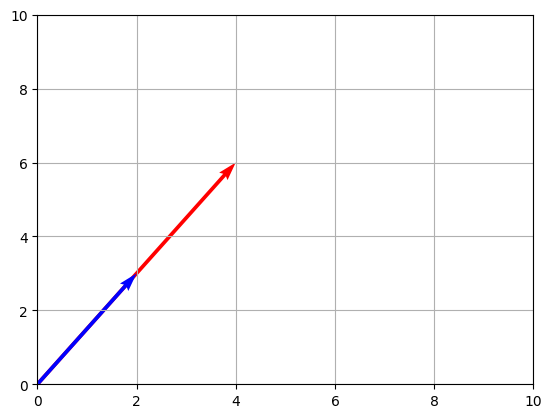

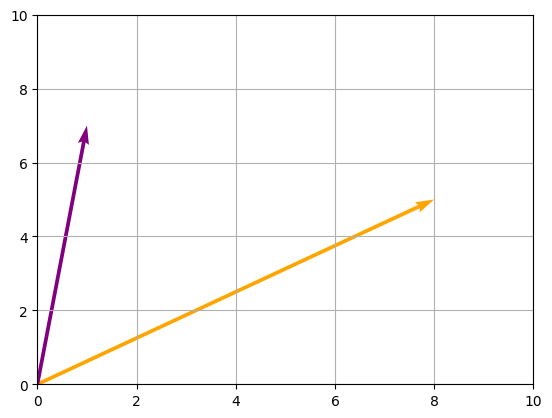

In [ ]:
# Geometric Interpretation

a = [2, 3]
b = [4, 6]
c = [8, 5]
d = [1, 7]

# linear dependence
plt.quiver(0, 0, b[0], b[1], scale_units="xy", angles="xy", scale=1, color="red")
plt.quiver(0, 0, a[0], a[1], scale_units="xy", angles="xy", scale=1, color="blue")

plt.xlim([0,10])
plt.ylim([0,10])

plt.grid()
plt.show()

# linear independence
plt.quiver(0, 0, c[0], c[1], scale_units="xy", angles="xy", scale=1, color="orange")
plt.quiver(0, 0, d[0], d[1], scale_units="xy", angles="xy", scale=1, color="purple")

plt.xlim([0,10])
plt.ylim([0,10])

plt.grid()
plt.show()


Since the vectors $\mathbf{a}, \mathbf{b},$ both lie on the same line, they are linearly dependent.  Vectors $\mathbf{c}, \mathbf{d},$ do not lie on the same line, and therefore could not be rewritten in terms of a linear combination of each other and are linearly independent.

The previous example can be extended to the basis of a space.  For some vectors $\mathbf{v}_1, \mathbf{v}_2, ..., \mathbf{v}_n$ to be a basis for some vector space $V$, the vectors need to be (1) linearly independent and (2) must span $V$.  In our example above, the vectors $\mathbf{c}, \mathbf{d},$ satisfy both qualifications for $\mathbb{R}^2,$ and thus form a basis for $\mathbb{R}^2$.

Since we can reach any point in $\mathbb{R}^2$ with our two vectors, adding any additional vectors would cause linear dependence.  This is because a third vector could be written as a linear combination of the other two.  Thus, the basis of $\mathbb{R}^2$ can at most be two vectors.  The vectors could be different and thus form a new basis (as long as they satisfy the 2 conditions), but they will always contain the same number of elements as any other basis.  This is known as the Dimension Theorem.

###1.2.2 - Orthogonality

The inner product of vectors can be written as $\langle\mathbf{x},\mathbf{y}\rangle = \mathbf{x}^T\mathbf{y}$.  The magnitude (also known as length or norm) can be written as $||\mathbf{x}|| = \sqrt{\langle\mathbf{x}, \mathbf{x}\rangle}$.  For Orthogonality, it must be that the inner product is equal to $0$.  A set of vectors $\mathbf{u}_1, \mathbf{u}_2, ..., \mathbf{u}_n$ are orthonormal if they are pairwise orthogonal, $(\langle\mathbf{u}_i, \mathbf{u}_j\rangle = 0$ for all $i$ and $i \ne j)$ and each has norm equal to $1$, or $||\mathbf{u}_i|| = 1$.

In [ ]:
# Orthogonal vectors
q = np.array([2, 0, 1])
w = np.array([-2, 5, 4])

print(np.inner(q, w))

0


The Pythagorean Theorem as most learn it is $a^2 + b^2 = c^2$.  We show this with orthogonal vectors $\mathbf{u}, \mathbf{v}$ as $||\mathbf{u} + \mathbf{v}||^2 = ||\mathbf{u}||^2 + ||\mathbf{v}||^2$.

In [ ]:
# Vectors
s = np.array([2, -3])
t = np.array([6, 4])

# Pythagorean ||u+v||^2
norm_st = (np.sqrt(np.dot(s+t, s+t)))**2
print(norm_st)

# Pythagorean ||u||^2 + ||v||^2
norm_st2 = (np.sqrt(np.dot(s,s)))**2 + (np.sqrt(np.dot(t,t)))**2
print(norm_st2)

64.99999999999999
64.99999999999999


Cauchy-Schwarz states that for any vectors $\mathbf{u},\mathbf{v}$ in some vector space $V,$ it will always be the case such that $|\langle\mathbf{u},\mathbf{v}\rangle| \le ||\mathbf{u}|| \: ||\mathbf{v}||$.

In [ ]:
def cauchy_schwarz(u,v):

  uv_dot = abs(np.sqrt(np.dot(u,v)))
  magu_magv = np.sqrt(np.dot(u,u)) * np.sqrt(np.dot(v,v))

  return print(f"{uv_dot:.2f} <= {magu_magv:.2f}.  Cauchy-Schwarz holds")

# Testing with vectors initialized throughout previous examples
cauchy_schwarz(s,t)
cauchy_schwarz(a,b)
cauchy_schwarz(q,w)
cauchy_schwarz(c,d)

0.00 <= 26.00.  Cauchy-Schwarz holds
5.10 <= 26.00.  Cauchy-Schwarz holds
0.00 <= 15.00.  Cauchy-Schwarz holds
6.56 <= 66.71.  Cauchy-Schwarz holds


Orthogonal Projection is a method used to "project" a vector to a point at a 90$^o$ angle to create a new projection vector.  This takes a vector, identifies a point on a line (or plane), and then finds a vector which is closest to connecting our initial vector and that point.

In [ ]:
def orthogonal_project(i,j):
  # projects the first vector onto the second vector
  proji_onj = (np.dot(i,j)/np.dot(j,j))*j
  return proji_onj

# Initializing new vectors
a_1 = np.array([4,5])
a_2 = np.array([7,3])

proj_vec = orthogonal_project(a_1, a_2)
print(proj_vec)

[5.18965517 2.22413793]


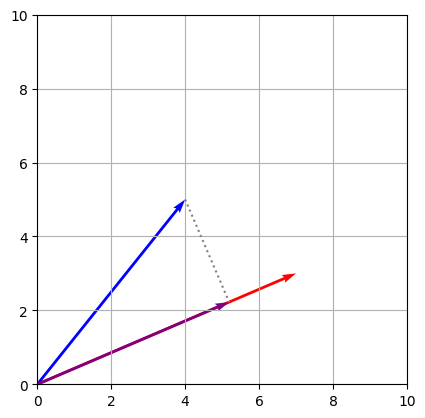

In [ ]:
# Geometrically showing projection

plt.quiver(0, 0, a_1[0], a_1[1], scale_units="xy", angles="xy", scale=1, color="blue")
plt.quiver(0, 0, a_2[0], a_2[1], scale_units="xy", angles="xy", scale=1, color="red")
plt.quiver(0, 0, proj_vec[0], proj_vec[1], scale_units="xy", angles="xy", scale=1, color="purple")

# Line connecting the vector to its projection
plt.plot([a_1[0], proj_vec[0]], [a_1[1], proj_vec[1]], linestyle=":", color="gray")

plt.xlim(0,10)
plt.ylim(0,10)

plt.grid()
plt.gca().set_aspect("equal")
plt.show()


###1.2.3 - Gram-Schmidt Process

The Gram-Schmidt Process is a way to construct an orthnormal basis for an inner product space $V$.  By taking projections to transform an ordinary basis $\{\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_n\}$ into an orthonormal basis $\{\mathbf{u}_1, \mathbf{u}_2, ..., \mathbf{u}_n\}$, we get $\mathbf{span}(\mathbf{u}_1, \mathbf{u}_2, ..., \mathbf{u}_k) = \mathbf{span}(\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_k)$ for $k = 1, ..., n$.

In [ ]:
def gram_schmidt(x, k):
  # x is basis
  # k is number of dimensions

  u = [] # new orthonormal basis

  for i in range(k):
    v = x[i].astype(float)

    for u_j in u:
      proj = np.inner(v, u_j)*u_j
      v = v - proj

    # Normalize
    u_i = v/np.sqrt(np.inner(v, v))
    u.append(u_i)

  return u

basis = [np.array([1, 1, 0]), np.array([1, 0, 1]), np.array([0, 1, 1])]
dim = len(basis)

orthonormal_basis = gram_schmidt(basis, dim)
print(orthonormal_basis)

[array([0.70710678, 0.70710678, 0.        ]), array([ 0.40824829, -0.40824829,  0.81649658]), array([-0.57735027,  0.57735027,  0.57735027])]


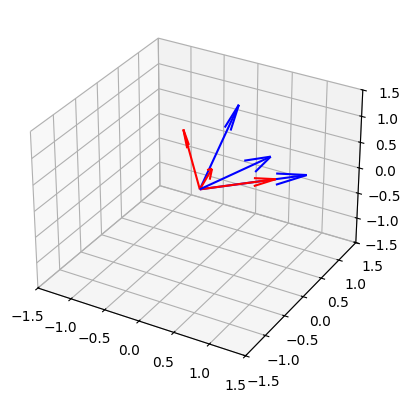

In [ ]:
# Graphing orthnormal basis and original basis

# Extracting Previous Vectors
q_1 = orthonormal_basis[0]
q_2 = orthonormal_basis[1]
q_3 = orthonormal_basis[2]

w_1 = basis[0]
w_2 = basis[1]
w_3 = basis[2]


# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.quiver(0, 0, 0, w_1[0], w_1[1], w_1[2], color="blue")
ax.quiver(0, 0, 0, w_2[0], w_2[1], w_2[2], color="blue")
ax.quiver(0, 0, 0, w_3[0], w_3[1], w_3[2], color="blue")

ax.quiver(0, 0, 0, q_1[0], q_1[1], q_1[2], color="red")
ax.quiver(0, 0, 0, q_2[0], q_2[1], q_2[2], color="red")
ax.quiver(0, 0, 0, q_3[0], q_3[1], q_3[2], color="red")

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)

plt.show()

###1.2.4 Eigenvalues and Eigenvectors

The Eigenvectors of a matrix are those nonzero vectors that, given a linear transformation, don't leave their original span.  The vector changes scale, but remains pointing the same direction.  The scale at which they change are known as eigenvalues.  Mathematically, it appears as such:  $A\mathbf{x}=\lambda\mathbf{x}$ and $\mathbf{x} \ne \mathbf{0}$.  

In [49]:
# Calculating the Eigenvectors and Eigenvalues of a 2x2 matrix
# In this example, there will only be real roots

A = [np.array([3, 3]), np.array([2, -2])]

lmda = sp.symbols('lmda')

# First, solve for eigenvalues
# Expanding equation
factor1 = A[0][0] - lmda
factor2 = A[1][1] - lmda
factor3 = A[0][1]*A[1][0]

quad_eq = sp.expand(factor1 * factor2)
eq = sp.Eq(quad_eq - factor3, 0)

# Using quadratic formula to find roots
aa = float(eq.lhs.coeff(lmda, 2))
bb = float(eq.lhs.coeff(lmda, 1))
cc = float(eq.lhs.coeff(lmda, 0))

discriminant = bb**2 - (4*aa*cc)
lambda1 = (-bb + np.sqrt(discriminant)) / 2*aa
lambda2 = (-bb - np.sqrt(discriminant)) / 2*aa

print(f"The eigenvalues are: {lambda1} and {lambda2}")

The eigenvalues are: 4.0 and -3.0


In [68]:
# Now solving for Eigenvectors
evec1 = []
evec2 = []

detA_4I = np.array([[A[0][0] - lambda1, A[0][1]],
                    [A[1][0], A[1][1] - lambda1]])

detA_3I = np.array([[A[0][0] - lambda2, A[0][1]],
                    [A[1][0], A[1][1] - lambda2]])

evec1.append(null_space(detA_4I)[0])
evec1.append(null_space(detA_4I)[1])
evec2.append(null_space(detA_3I)[0])
evec2.append(null_space(detA_3I)[1])

print(f"The eigenvector for lambda1 = 4: {evec1}\nThe eigenvector for lambda2 = -3 is: {evec2}")

The eigenvector for lambda1 = 4: [array([-0.9486833]), array([-0.31622777])]
The eigenvector for lambda2 = -3 is: [array([-0.4472136]), array([0.89442719])]


In [48]:
# Checking to see if they are the same with numpy library
eigenvals, eigenvecs = np.linalg.eig(A)

print(f"{eigenvals}\n")
print(f"{eigenvecs}")

[ 4. -3.]

[[ 0.9486833  -0.4472136 ]
 [ 0.31622777  0.89442719]]


Our manual calculation got some of the values as negatives, but this does not matter.  It's all scaled the same way.  The eigenvectors all point along the same line through the origin.